# Hito 1:

1. [Descripcion del dataset](##-1.-Descripción-del-Dataset)

2. [Primeros modelos](##-2.-Implementacion-Primeros-Modelos)

In [ ]:
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas

In [ ]:
!{sys.executable} -m pip install wordcloud

## 1. Descripción del Dataset

In [ ]:
import pandas as pd

music_file = pd.read_csv('spotify_dataset.csv', sep=',', on_bad_lines='skip')
music_file.head()

,user_id,"""artistname""","""trackname""","""playlistname"""
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [21]:
music_file.columns = ['user_id', 'artist_name', 'track_name', 'playlist_name']
print(music_file.columns)

Index(['user_id', 'artist_name', 'track_name', 'playlist_name'], dtype='object')


### Cantidad de Filas y Columnas

In [22]:
filas = music_file.shape[0]
columnas = music_file.shape[1]
print(f"Filas: {filas}\nColumnas: {columnas}")

Filas: 12891680
Columnas: 4


### Valores Nulos

In [10]:
print("Valores nulos por columna:\n\n", music_file.isnull().sum())
# music_file = music_file.drop_duplicates()

Valores nulos por columna:

 user_id                0
 "artistname"      33572
 "trackname"          88
 "playlistname"     1246
dtype: int64


### Duplicados

In [11]:
print("Filas duplicadas:", music_file.duplicated().sum())


Filas duplicadas: 3


### Estadisticas de Cada Columna

In [24]:
estadisticas = music_file.describe(include=['object'])
print(estadisticas)

                                 user_id artist_name track_name playlist_name
count                           12891680    12858108   12891592      12890434
unique                             15918      289820    2032043        157504
top     4398de6902abde3351347b048fcdc287   Daft Punk      Intro       Starred
freq                              295275       36086       6676       1337085


Hay en total:

* 15.918 Usuarios
* 289.820 Artistas
* 2.032.043 Canciones
* 157.504 Playlists

El artista mas escuchado es Daft Punk con un total de 36086 canciones guardadas en playlists

### Top 10 Artistas con mas Canciones en el Dataset

In [23]:
top_artistas = music_file['artist_name'].value_counts().head(10)
print("Top 10 Artistas:\n", top_artistas)

Top 10 Artistas:
 artist_name
Daft Punk             36086
Coldplay              35485
Radiohead             31429
The Rolling Stones    30832
Kanye West            29111
JAY Z                 28928
Eminem                28894
Queen                 28079
David Bowie           27802
Michael Jackson       26336
Name: count, dtype: int64


Cada valor representa cuántas veces aparece cada artista en total dentro de todas las playlists del dataset

Si una persona agrego 5 canciones del mismo artista, cuentan las 5 veces

### Top 10 Canciones en el Dataset

In [27]:
top_canciones = music_file.groupby(['artist_name', 'track_name']).size()
top_canciones = top_canciones.sort_values(ascending=False).head(10)

print("Top 10 Canciones:\n", top_canciones)

Top 10 Canciones:
 artist_name              track_name                      
M83                      Midnight City                       2609
Daft Punk                Get Lucky - Radio Edit              2341
Imagine Dragons          Radioactive                         2336
Of Monsters and Men      Little Talks                        2254
Avicii                   Wake Me Up                          2242
Lorde                    Royals                              2219
The Lumineers            Ho Hey                              2180
Macklemore & Ryan Lewis  Can't Hold Us - feat. Ray Dalton    2066
Bastille                 Pompeii                             2014
Robin Thicke             Blurred Lines                       1996
dtype: int64


Cada valor representa cuántas veces aparece cada cancion en total dentro de todas las playlists del dataset

### Top 20 Canciones en el Dataset

C:\Users\mayit\AppData\Local\Temp\ipykernel_23328\1768146785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_canciones.values, y=nombres_eje_y, palette="magma")


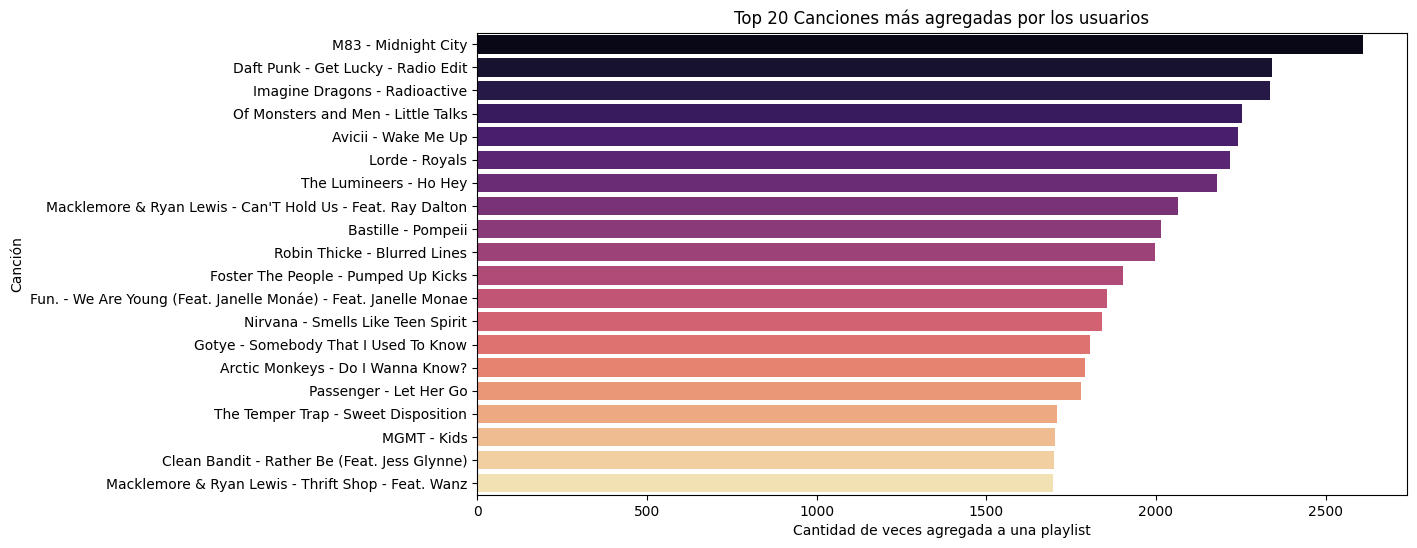

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

top_canciones = music_file.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False).head(20)
nombres_eje_y = [f"{artista} - {cancion.title()}" for artista, cancion in top_canciones.index]

sns.barplot(x=top_canciones.values, y=nombres_eje_y, palette="magma")

plt.title('Top 20 Canciones más agregadas por los usuarios')
plt.xlabel('Cantidad de veces agregada a una playlist')
plt.ylabel('Canción')
plt.show()

### Cantidad de Canciones por Playlist

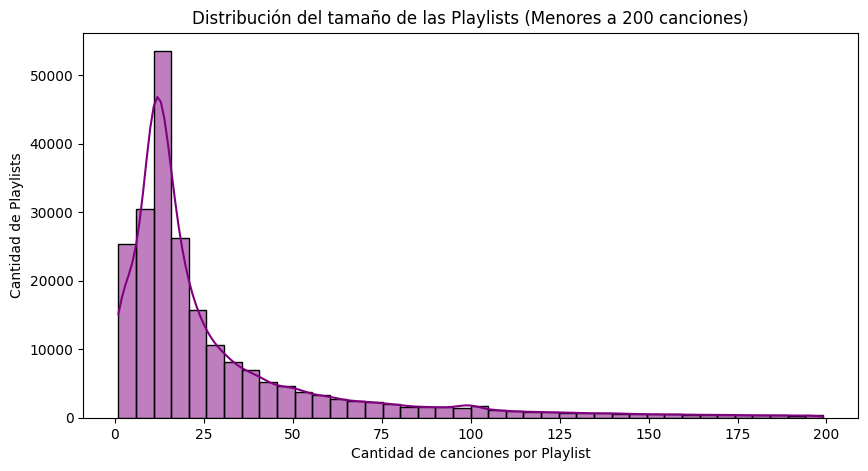

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

tamano_playlists = music_file.groupby(['user_id', 'playlist_name']).size()

plt.figure(figsize=(10, 5))
sns.histplot(tamano_playlists[tamano_playlists < 200], bins=40, color='purple', kde=True)

plt.title('Distribución del tamaño de las Playlists (Menores a 200 canciones)')
plt.xlabel('Cantidad de canciones por Playlist')
plt.ylabel('Cantidad de Playlists')
plt.show()

La gente suele tener aproximadamente ~15 canciones por playlist

### Top 10 Usuarios con mas Canciones Guardadas

C:\Users\mayit\AppData\Local\Temp\ipykernel_23328\3608074929.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etiquetas_usuarios, y=top_usuarios.values, palette="Blues_r")


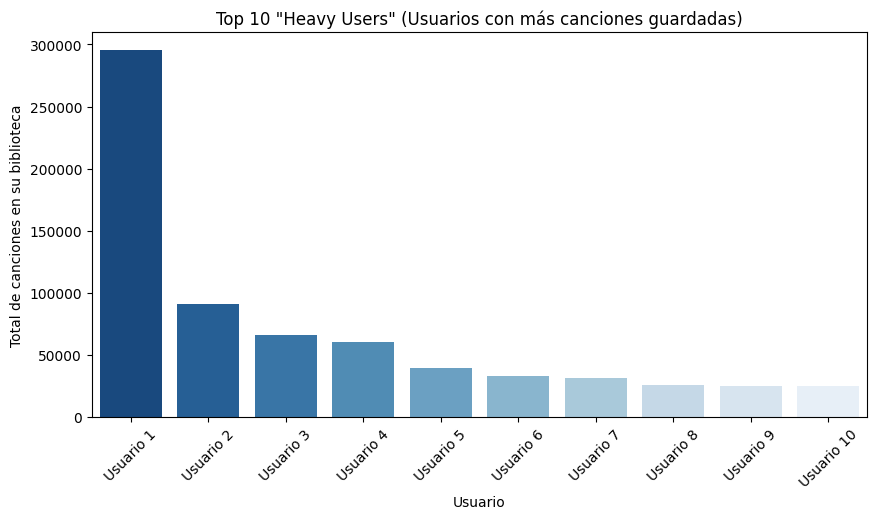

In [ ]:
plt.figure(figsize=(10, 5))
top_usuarios = music_file['user_id'].value_counts().head(10)
etiquetas_usuarios = [f"Usuario {i+1}" for i in range(len(top_usuarios))]
sns.barplot(x=etiquetas_usuarios, y=top_usuarios.values, palette="Blues_r")

plt.title('Top 10 "Heavy Users" (Usuarios con más canciones guardadas)')
plt.xlabel('Usuario')
plt.ylabel('Total de canciones en su biblioteca')
plt.xticks(rotation=45)
plt.show()

En conclusion, hay un loco que tiene casi 300.000 canciones guardadas 💀

### Cantidad de Palabras mas Usadas por Playlist

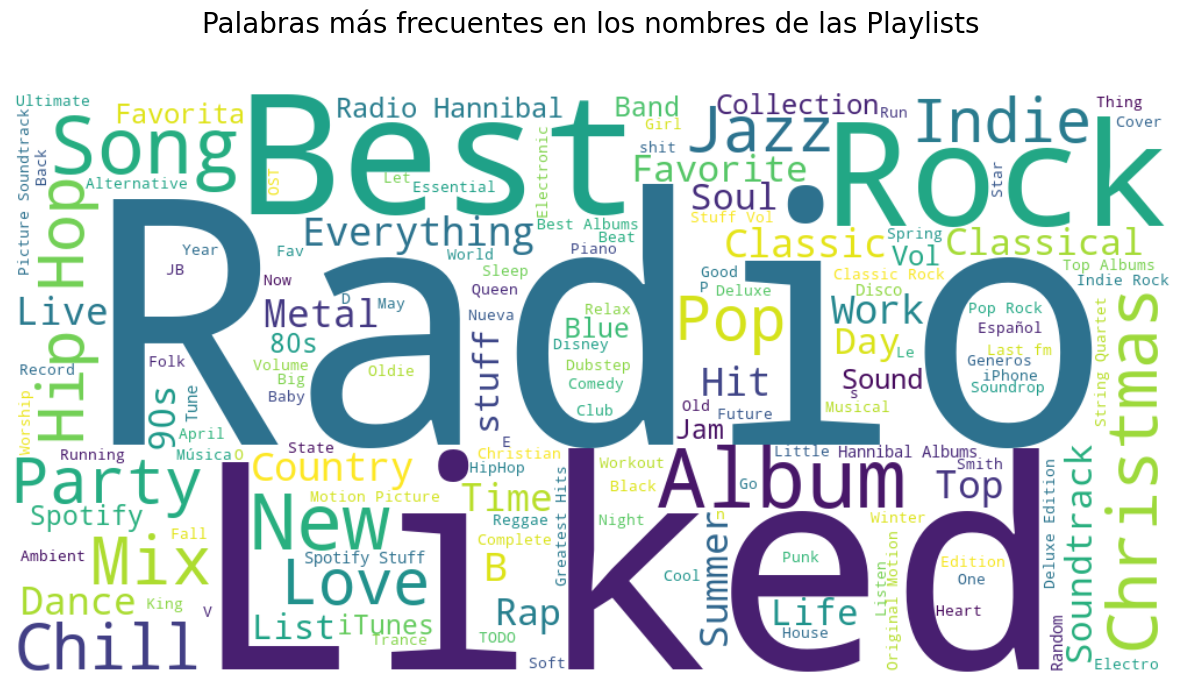

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

nombres_playlists = music_file['playlist_name'].dropna().sample(n=50000, random_state=42)
texto_completo = " ".join(nombres_playlists.astype(str))

palabras_ignoradas = set(STOPWORDS)
palabras_ignoradas.update([
    "playlist", "music", "musica", "lista", "canciones", 
    "de", "la", "el", "en", "y", "los", "las", "para", "a", # preposiciones español
    "Starred", "Library", "Streams", "Various", "Artists", "Part", "Track" # listas automáticas
])

wordcloud = WordCloud(
    width=1000,            
    height=500,               
    background_color='white', 
    stopwords=palabras_ignoradas,
    colormap='viridis',         # otras opciones: 'viridis', 'plasma', 'inferno'
    max_words=150    
).generate(texto_completo)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('Palabras más frecuentes en los nombres de las Playlists\n', fontsize=20, pad=20)
plt.show()

Esta nube de palabras nos revela varias cosas:

1. Los estilos de musica predominantes entre usuarios
2. El contexto tambien influye en la musica que escuchamos (Christmas (Navidad), Summer (Verano), Party (Fiesta), Chill (Relajo) o Work (Trabajo))
3. Las playlists mas escuchadas son las que el mismo Spotify genera (por la palabra Radio)

## 2. Implementacion Primeros Modelos

### Split Train Set y Test Set

In [ ]:
import pandas as pd
import random

music_file['cancion_id'] = music_file['artist_name'] + " - " + music_file['track_name']
playlists_series = music_file.groupby(['user_id', 'playlist_name'])['cancion_id'].apply(list)
playlists_validas = [playlist for playlist in playlists_series if len(playlist) >= 3]

print(f"Total de playlists listas para procesar: {len(playlists_validas)}")

Total de playlists listas para procesar: 217770


In [ ]:
train_playlists = []
test_playlists = []

for playlist in playlists_validas:
    train_playlists.append(playlist[:-1])
    test_playlists.append(playlist[-1])

print("Ejemplo Train:", train_playlists[0])
print("Ejemplo Test (Oculta):", test_playlists[0])

Ejemplo Train: ['Jannik Brunke - 18', 'Green Day - 21 Guns', 'Shawn Mendes - A Little Too Much', 'One Direction - Act My Age', 'blink-182 - After Midnight', 'Meghan Trainor - All About That Bass', 'Ed Sheeran - All Of The Stars', 'Green Day - American Idiot', 'Maroon 5 - Animals', 'Against The Current - Another You (Another Way)', "Bmike - Baby Don't Cut", 'All Time Low - Backseat Serenade', 'Meghan Tonjes - Blank Space', 'Charli XCX - Boom Clap', 'Little Mix - Boy', 'All Time Low - Break Your Little Heart', 'High School Musical Cast - Breaking Free', 'The Cat Empire - Brighter Than Gold', 'Shawn Mendes - Bring It Back', 'Gerard Way - Brother', 'OneRepublic - Burning Bridges', 'Fall Out Boy - Centuries', 'Little Mix - Change Your Life', 'The 1975 - Chocolate', 'Against The Current - Closer, Faster', 'All Time Low - Dear Maria, Count Me In', '5 Seconds Of Summer - Disconnected', "Ed Sheeran - Don't", "5 Seconds Of Summer - Don't Stop - Acoustic", '5 Seconds Of Summer - English Love Affa

### Random y Most Popular

In [68]:
import random

todas_las_canciones_train = [cancion for playlist in train_playlists for cancion in playlist]
top_10_popular = pd.Series(todas_las_canciones_train).value_counts().head(10).index.tolist()

print("\nRecomendación Most Popular (Para todos igual):")
print(top_10_popular[:3])

canciones_unicas = list(set(todas_las_canciones_train))

K = 10

aciertos_popular = 0
aciertos_random = 0

total_evaluar = len(test_playlists)

print(f"Evaluando modelos en {total_evaluar} playlists ocultas...\n")

for i in range(total_evaluar):
    cancion_oculta = test_playlists[i]

    if cancion_oculta in top_10_popular[:K]:
        aciertos_popular += 1
        
    recomendacion_random = random.sample(canciones_unicas, K)
    
    if cancion_oculta in recomendacion_random:
        aciertos_random += 1

hit_rate_popular = (aciertos_popular / total_evaluar) * 100
hit_rate_random = (aciertos_random / total_evaluar) * 100

print("=== RESULTADOS (HIT RATE @ 10) ===")
print(f"Modelo Random:       {hit_rate_random:.4f}% de aciertos")
print(f"Modelo Most Popular: {hit_rate_popular:.4f}% de aciertos")


Recomendación Most Popular (Para todos igual):
['M83 - Midnight City', 'Daft Punk - Get Lucky - Radio Edit', 'Imagine Dragons - Radioactive']
Evaluando modelos en 217770 playlists ocultas...

=== RESULTADOS (HIT RATE @ 10) ===
Modelo Random:       0.0000% de aciertos
Modelo Most Popular: 0.0859% de aciertos


### Modelo Particular al Problema: Content-Based (Texto)

Ideal para este caso ya que toma en cuenta de que tratan las canciones, el nombre de las playlists, etc.

In [69]:
import pandas as pd
import numpy as np

music_file['cancion_id'] = music_file['artist_name'] + " - " + music_file['track_name']
canciones_desc = music_file.groupby('cancion_id')['playlist_name'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

print("Ejemplo de ítem y su descripción (contenido):")
print(canciones_desc.head(2))

Ejemplo de ítem y su descripción (contenido):
             cancion_id                                  playlist_name
0   Dolce - Hand i hand            Everything at once May 2015 öh höst
1   Dolce - Inez Palema  Everything at once May 2015 Sweden, sometimes


En el practico usado como referencia para esta implementacion (Content-Based Texto) se utiliza BERT y PCA, aca usaremos un analogo, TfidfVectorizer, para leer las palabras y convertirlas en números.

In [ ]:
## IMPORTANTE: Esta celda no fue ejecutada durante el entrenamiento, ya que el total de datos es 5 veces mas de lo que fue usado finalmente
## No hay RAM que aguante tal cantidad considerando que el algoritmo crea matrices densas gigantes y los calculos matematicos explotan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(canciones_desc['playlist_name'])

svd = TruncatedSVD(n_components=20, random_state=42)
pca20_spotify_featmat = svd.fit_transform(tfidf_matrix)

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("Total de canciones originales:", music_file['cancion_id'].nunique())

# este filtro toma solo las canciones relevantes que aparecen en 5 playlists o mas, de esta manera se evita usar todo el dataset y que explote la RAM
conteo_canciones = music_file['cancion_id'].value_counts()
canciones_validas = conteo_canciones[conteo_canciones >= 5].index

music_file_filtrado = music_file[music_file['cancion_id'].isin(canciones_validas)].copy()
print("Total de canciones después de filtrar (Dataset más liviano):", music_file_filtrado['cancion_id'].nunique())

canciones_desc = music_file_filtrado.groupby('cancion_id')['playlist_name'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

print("Calculando TF-IDF...")
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(canciones_desc['playlist_name'])

print("Ejecutando SVD (Reducción de dimensionalidad)...")
svd = TruncatedSVD(n_components=20, random_state=42)
pca20_spotify_featmat = svd.fit_transform(tfidf_matrix)

print("Forma de nuestra matriz de características:", pca20_spotify_featmat.shape)

Total de canciones originales: 2790788
Total de canciones después de filtrar (Dataset más liviano): 435683
Calculando TF-IDF...
Ejecutando SVD (Reducción de dimensionalidad)...
Forma de nuestra matriz de características: (435683, 20)


In [75]:
idx2cancionid = {i: id_ for i, id_ in enumerate(canciones_desc['cancion_id'])}
cancionid2idx = {id_: i for i, id_ in enumerate(canciones_desc['cancion_id'])}

user_interactions = music_file.groupby('user_id')['cancion_id'].apply(list).to_dict()

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances

def recommend_spotify(embedding, user_id, topk=10, metric='cosine'):
    user_id = str(user_id)
    
    if user_id not in user_interactions:
        return []
    
    trx = user_interactions[user_id]
    
    query_indices = [cancionid2idx[t] for t in trx if t in cancionid2idx]
    
    if not query_indices:
        return []

    distancias_minimas = np.full(embedding.shape[0], np.inf)
    
    # disminuir este numero si al testear se obtiene MemoryError
    batch_size = 500
    for i in range(0, len(query_indices), batch_size):
        bloque = query_indices[i : i + batch_size]
        
        distancias_bloque = pairwise_distances(embedding[bloque], embedding, metric=metric)
        min_bloque = np.min(distancias_bloque, axis=0)
        distancias_minimas = np.minimum(distancias_minimas, min_bloque)

    distancias_minimas[query_indices] = np.inf
    
    if len(distancias_minimas) > topk:
        mejores_indices = np.argpartition(distancias_minimas, topk)[:topk]
        mejores_indices = mejores_indices[np.argsort(distancias_minimas[mejores_indices])]
    else:
        mejores_indices = np.argsort(distancias_minimas)
        
    recommended_ids = [idx2cancionid[i] for i in mejores_indices]

    return recommended_ids

In [81]:
user_interactions_train = {}
user_interactions_test = {}

for user, canciones in user_interactions.items():
    if len(canciones) >= 2:
        user_interactions_train[user] = canciones[:-1]
        user_interactions_test[user] = [canciones[-1]]

user_interactions = user_interactions_train

print(f"Usuarios: {len(user_interactions_test)}")

Usuarios: 15497


### Evaluacion

Definicion de metricas de evaluacion

In [82]:
# Métricas de evaluación
# Obtenido de https://gist.github.com/bwhite/3726239

def precision_at_k(r, k):
    assert k >= 1
    r = np.asarray(r)[:k] != 0
    if r.size != k:
        raise ValueError('Relevance score length < k')
    return np.mean(r)

def average_precision(r):
    r = np.asarray(r) != 0
    out = [precision_at_k(r, k + 1) for k in range(r.size) if r[k]]
    if not out:
        return 0.
    return np.mean(out)

def mean_average_precision(rs):
    return np.mean([average_precision(r) for r in rs])

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg


Evaluacion del modelo

In [88]:
import time

start = time.time()

mean_map = 0.
mean_ndcg = 0.
topk = 10

usuarios_a_evaluar = list(user_interactions_test.keys())[:1000]

print(f"Iniciando evaluación para {len(usuarios_a_evaluar)} usuarios...")

for i, u in enumerate(usuarios_a_evaluar):
    print(f"Evaluando... {i+1}/{len(usuarios_a_evaluar)}", end='\r')
    rec = recommend_spotify(pca20_spotify_featmat, user_id=u, topk=topk)
    rel_vector = np.isin(rec, user_interactions_test[u]).astype(int)
    rel_vector_list = [rel_vector]
    mean_map += mean_average_precision(rel_vector_list)
    mean_ndcg += ndcg_at_k(rel_vector, topk)

# promedio final
mean_map /= len(usuarios_a_evaluar)
mean_ndcg /= len(usuarios_a_evaluar)

time_taken = time.time() - start

print("\n\n=== RESULTADOS CONTENT-BASED (TF-IDF + SVD) ===")
print(f"MAP:        {mean_map:.4f}")
print(f"nDCG@10:    {mean_ndcg:.4f}")
print(f"Tiempo:     {time_taken:.2f} segundos")

Iniciando evaluación para 1000 usuarios...
Evaluando... 1000/1000

=== RESULTADOS CONTENT-BASED (TF-IDF + SVD) ===
MAP:        0.0217
nDCG@10:    0.0263
Tiempo:     2821.36 segundos


Se demoro casi 1 hora, y las metricas son peores que most popular 😔

Pero al menos no fue 0, lo que significa que algo aprendio

Es un buen punto de partida